<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/Fundamentals_and_Applications/dz_topic_10_Sofiia_Bobrivets_AL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання до теми 10
## Вступ до генерації ознак. Відбір ознак

**Студентка:** Sofiia Bobrivets  
**Курс:** Machine Learning: Fundamentals and Applications

### Мета роботи
На наборі даних **Autos** порівняти два підходи до оцінювання «корисності» вхідних ознак для прогнозування `price`:

- взаємну інформацію (`mutual_info_regression`);
- важливість ознак у регресійній моделі (`RandomForestRegressor`).

Для коректного порівняння обидва показники буде переведено у процентні ранги за допомогою `.rank(pct=True)`.


## 1. Імпорт бібліотек

In [14]:
import pickle
import urllib.request
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


## 2. Завантаження набору Autos

У матеріалах курсу набори для цієї теми зберігаються у файлі `mod_05_topic_10_various_data.pkl`.  
Ноутбук завантажує файл із репозиторію GoIT і вибирає набір `autos`.


In [15]:
url = "https://github.com/goitacademy/MACHINE-LEARNING-NEO/raw/refs/heads/main/datasets/mod_05_topic_10_various_data.pkl"
file_name = "mod_05_topic_10_various_data.pkl"

urllib.request.urlretrieve(url, file_name)

with open(file_name, "rb") as file:
    data = pickle.load(file)

print("Доступні набори:", list(data.keys()))

autos = data["autos"].copy()

print("\nРозмір Autos:", autos.shape)
display(autos.head())


Доступні набори: ['autos', 'concrete', 'customer', 'accidents']

Розмір Autos: (193, 24)


,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9,111,5000,21,27,13495
1,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9,111,5000,21,27,16500
2,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
3,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.40,10,102,5500,24,30,13950
4,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.40,8,115,5500,18,22,17450


## 3. Первинний аналіз і підготовка даних

In [16]:
TARGET = "price"

# Видаляємо рядки без цільової змінної
df = autos.dropna(subset=[TARGET]).copy()

X_raw = df.drop(columns=[TARGET])
y = df[TARGET].astype(float)

# Категоріальні ознаки
categorical_features = X_raw.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Числові ознаки, які за змістом є дискретними
discrete_numeric_features = [
    "num_of_doors",
    "num_of_cylinders"
]

# Повний перелік дискретних ознак
discrete_features = (
    categorical_features
    + discrete_numeric_features
)

print("Категоріальні ознаки:")
print(categorical_features)

print("\nДискретні числові ознаки:")
print(discrete_numeric_features)

print("\nУсі дискретні ознаки:")
print(discrete_features)


Категоріальні ознаки:
['make', 'fuel_type', 'aspiration', 'body_style', 'drive_wheels', 'engine_location', 'engine_type', 'fuel_system']

Дискретні числові ознаки:
['num_of_doors', 'num_of_cylinders']

Усі дискретні ознаки:
['make', 'fuel_type', 'aspiration', 'body_style', 'drive_wheels', 'engine_location', 'engine_type', 'fuel_system', 'num_of_doors', 'num_of_cylinders']


### Кодування і заповнення пропусків

`mutual_info_regression()` потребує числового представлення ознак. Категоріальні поля кодуємо `OrdinalEncoder`, а пропуски заповнюємо окремо для числових і категоріальних ознак.

Те саме числове представлення використаємо для `RandomForestRegressor`, щоб MI та feature importance порівнювалися для однакового набору вхідних ознак.


In [17]:
X = X_raw.copy()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()

# Числові пропуски -> медіана
if numeric_features:
    num_imputer = SimpleImputer(strategy="median")
    X[numeric_features] = num_imputer.fit_transform(X[numeric_features])

# Категоріальні пропуски -> найчастіше значення, потім ordinal encoding
if categorical_features:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_cat = cat_imputer.fit_transform(X[categorical_features])

    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )
    X[categorical_features] = encoder.fit_transform(X_cat)

# На випадок, якщо після конвертації залишилися нечислові колонки
non_numeric = X.select_dtypes(exclude=np.number).columns.tolist()
if non_numeric:
    raise ValueError(f"Залишилися нечислові ознаки: {non_numeric}")

print("Підготовлений X:", X.shape)
print("Пропусків:", X.isna().sum().sum())
display(X.head())


Підготовлений X: (193, 23)
Пропусків: 0


,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
0,0.0,1.0,0.0,2.0,0.0,2.0,0.0,88.6,168.8,64.1,48.8,2548.0,0.0,4.0,130.0,4.0,3.47,2.68,9.0,111.0,5000.0,21.0,27.0
1,0.0,1.0,0.0,2.0,0.0,2.0,0.0,88.6,168.8,64.1,48.8,2548.0,0.0,4.0,130.0,4.0,3.47,2.68,9.0,111.0,5000.0,21.0,27.0
2,0.0,1.0,0.0,2.0,2.0,2.0,0.0,94.5,171.2,65.5,52.4,2823.0,4.0,6.0,152.0,4.0,2.68,3.47,9.0,154.0,5000.0,19.0,26.0
3,1.0,1.0,0.0,4.0,3.0,1.0,0.0,99.8,176.6,66.2,54.3,2337.0,2.0,4.0,109.0,4.0,3.19,3.40,10.0,102.0,5500.0,24.0,30.0
4,1.0,1.0,0.0,4.0,3.0,0.0,0.0,99.4,176.6,66.4,54.3,2824.0,2.0,5.0,136.0,4.0,3.19,3.40,8.0,115.0,5500.0,18.0,22.0


## 4. Взаємна інформація між ознаками та `price`

In [18]:
# Булева маска: True для дискретних ознак.
discrete_mask = np.array([
    column in discrete_features
    for column in X.columns
])

mi_values = mutual_info_regression(
    X,
    y,
    discrete_features=discrete_mask,
    random_state=RANDOM_STATE
)

mi = pd.Series(
    mi_values,
    index=X.columns,
    name="mutual_information"
).sort_values(ascending=False)

display(mi.to_frame())


,mutual_information
curb_weight,0.911713
engine_size,0.900925
horsepower,0.891165
highway_mpg,0.887362
city_mpg,0.774127
width,0.679991
length,0.612483
wheel_base,0.588635
make,0.543268
bore,0.497420


## 5. Random Forest та важливість ознак

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

model = RandomForestRegressor(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")


R²:  0.9321
MAE: 1615.58


In [20]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns,
    name="feature_importance"
).sort_values(ascending=False)

display(feature_importance.to_frame())


,feature_importance
curb_weight,0.440075
engine_size,0.433880
horsepower,0.020134
width,0.017711
highway_mpg,0.014108
make,0.013922
num_of_cylinders,0.009660
length,0.006930
height,0.006291
wheel_base,0.005626


## 6. Уніфікація показників через процентні ранги

In [21]:
comparison = pd.concat(
    [mi, feature_importance],
    axis=1
)

comparison["MI_rank"] = (
    comparison["mutual_information"]
    .rank(pct=True)
)

comparison["Importance_rank"] = (
    comparison["feature_importance"]
    .rank(pct=True)
)

comparison = comparison.sort_values(
    "Importance_rank",
    ascending=False
)

display(comparison)


,mutual_information,feature_importance,MI_rank,Importance_rank
curb_weight,0.911713,0.440075,1.000000,1.000000
engine_size,0.900925,0.433880,0.956522,0.956522
horsepower,0.891165,0.020134,0.913043,0.913043
width,0.679991,0.017711,0.782609,0.869565
highway_mpg,0.887362,0.014108,0.869565,0.826087
make,0.543268,0.013922,0.652174,0.782609
num_of_cylinders,0.330589,0.009660,0.391304,0.739130
length,0.612483,0.006930,0.739130,0.695652
height,0.368335,0.006291,0.478261,0.652174
wheel_base,0.588635,0.005626,0.695652,0.608696


## 7. Порівняльна візуалізація

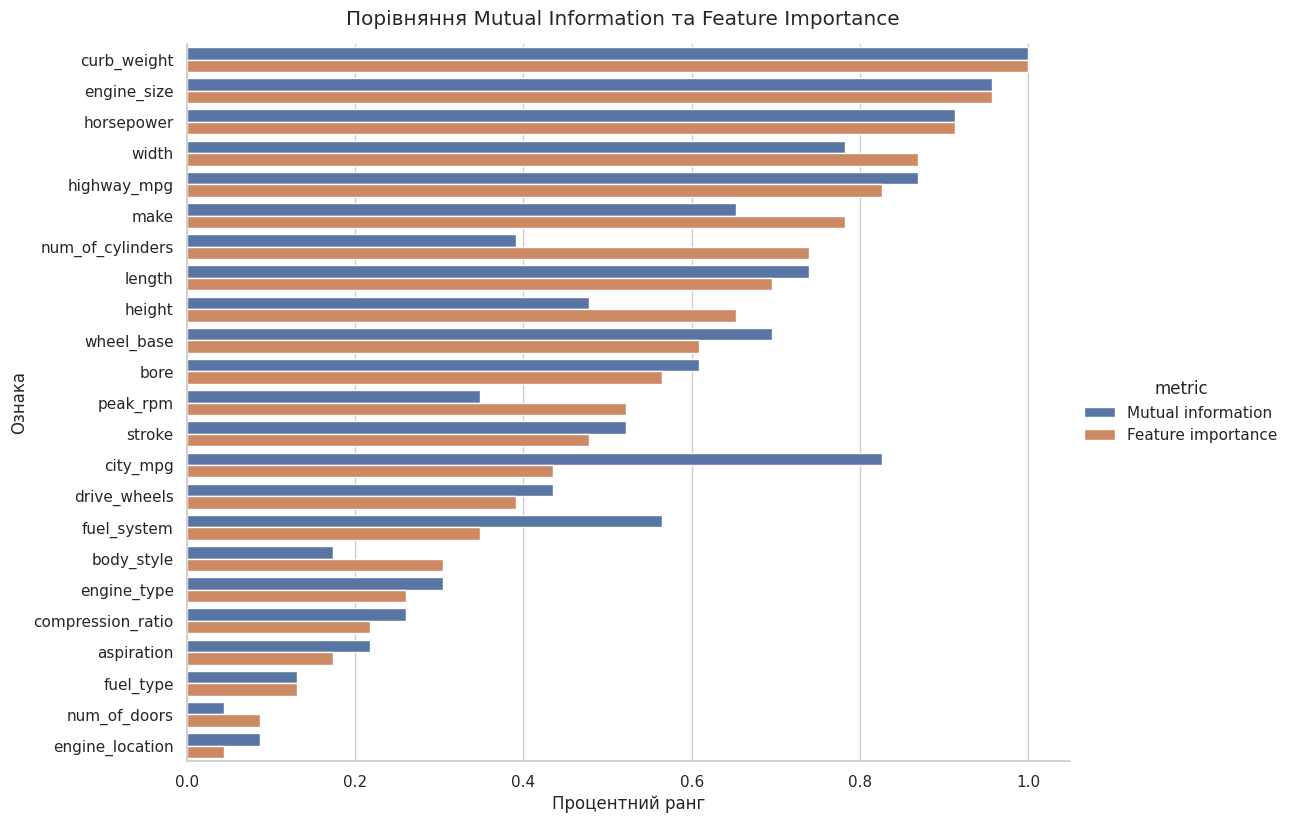

In [22]:
plot_data = (
    comparison[["MI_rank", "Importance_rank"]]
    .reset_index()
    .rename(columns={"index": "feature"})
    .melt(
        id_vars="feature",
        var_name="metric",
        value_name="rank"
    )
)

plot_data["metric"] = plot_data["metric"].replace({
    "MI_rank": "Mutual information",
    "Importance_rank": "Feature importance"
})

g = sns.catplot(
    data=plot_data,
    kind="bar",
    x="rank",
    y="feature",
    hue="metric",
    height=max(6, 0.35 * len(comparison)),
    aspect=1.4
)

g.set_axis_labels("Процентний ранг", "Ознака")
g.fig.suptitle(
    "Порівняння Mutual Information та Feature Importance",
    y=1.02
)

plt.show()


## 8. Аналіз результатів

Для зручності окремо виведемо ознаки з найбільшою взаємною інформацією та ознаки, які Random Forest використовує найактивніше.


In [23]:
print("TOP-5 за Mutual Information:")
display(
    comparison
    .sort_values("mutual_information", ascending=False)
    [["mutual_information", "MI_rank"]]
    .head(5)
)

print("TOP-5 за Feature Importance:")
display(
    comparison
    .sort_values("feature_importance", ascending=False)
    [["feature_importance", "Importance_rank"]]
    .head(5)
)


TOP-5 за Mutual Information:


,mutual_information,MI_rank
curb_weight,0.911713,1.000000
engine_size,0.900925,0.956522
horsepower,0.891165,0.913043
highway_mpg,0.887362,0.869565
city_mpg,0.774127,0.826087


TOP-5 за Feature Importance:


,feature_importance,Importance_rank
curb_weight,0.440075,1.000000
engine_size,0.433880,0.956522
horsepower,0.020134,0.913043
width,0.017711,0.869565
highway_mpg,0.014108,0.826087


## Висновки

У роботі було досліджено два способи оцінювання корисності ознак для прогнозування ціни автомобіля.

Показник **Mutual Information** оцінює статистичну залежність окремої вхідної ознаки від цільової змінної `price`. Натомість **feature importance** моделі Random Forest характеризує те, наскільки активно конкретна ознака використовується ансамблем дерев під час побудови прогнозів разом з іншими ознаками.

Оскільки ці показники мають різну природу та масштаб, для їх порівняння було використано процентні ранги `.rank(pct=True)`. Порівняльна візуалізація дозволяє побачити, що порядок ознак за Mutual Information та за важливістю в Random Forest може відрізнятися.

Отже, низьке або високе значення Mutual Information саме по собі не визначає остаточну корисність ознаки для конкретної прогнозної моделі. Під час відбору ознак доцільно враховувати як статистичний зв'язок із цільовою змінною, так і поведінку ознак безпосередньо в моделі.
